<a href="https://colab.research.google.com/github/PittuSaiPrathvik/xyz/blob/main/Machine_Learning_week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported.")

Libraries imported.


In [4]:
os.makedirs("week3_outputs", exist_ok=True)
os.makedirs("week3_outputs/figures", exist_ok=True)
os.makedirs("week3_outputs/tables", exist_ok=True)
os.makedirs("week3_outputs/model", exist_ok=True)

In [6]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch the Student Performance dataset (id: 320)
student_performance = fetch_ucirepo(id=320)

# Get data as pandas DataFrame
df_features = student_performance.data.features
df_targets = student_performance.data.targets

# Full DataFrame containing all features and targets
df = pd.concat([df_features, df_targets], axis=1)

print("Dataset shape:", df.shape)

Dataset shape: (649, 33)


In [7]:
df["performance"] = np.where(
    df["G3"] >= 10,
    "Pass",
    "Fail"
)

print(
    df["performance"].value_counts()
)

performance
Pass    549
Fail    100
Name: count, dtype: int64


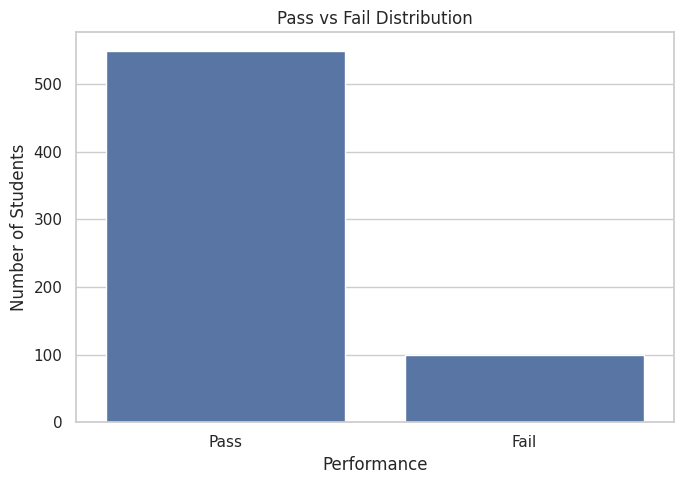

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="performance"
)

plt.title("Pass vs Fail Distribution")
plt.xlabel("Performance")
plt.ylabel("Number of Students")

plt.tight_layout()

plt.savefig(
    "week3_outputs/figures/pass_fail_distribution.png",
    dpi=300
)

plt.show()

In [9]:
columns_to_remove = [
    "G1",
    "G2",
    "G3",
    "performance"
]

X = df.drop(
    columns=columns_to_remove
)

y = df["performance"]

print("Features used:")
print(X.columns.tolist())

Features used:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [10]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 519
Testing samples: 130


In [12]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [13]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}

print("Four models prepared.")

Four models prepared.


In [14]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

    print(
        name,
        "trained successfully."
    )

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [15]:
results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    actual_binary = (
        y_test == "Pass"
    ).astype(int)

    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                predictions
            ),

        "Precision":
            precision_score(
                y_test,
                predictions,
                pos_label="Pass"
            ),

        "Recall":
            recall_score(
                y_test,
                predictions,
                pos_label="Pass"
            ),

        "F1 Score":
            f1_score(
                y_test,
                predictions,
                pos_label="Pass"
            ),

        "ROC AUC":
            roc_auc_score(
                actual_binary,
                probabilities
            )
    })

results_df = pd.DataFrame(
    results
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.792308,0.867257,0.890909,0.878924,0.622727
1,Decision Tree,0.753846,0.848214,0.863636,0.855856,0.589318
2,Random Forest,0.807692,0.857143,0.927273,0.890830,0.679545
3,Gradient Boosting,0.792308,0.873874,0.881818,0.877828,0.671364


In [16]:
results_df.to_csv(
    "week3_outputs/tables/model_comparison.csv",
    index=False
)

print("Model results saved.")

Model results saved.


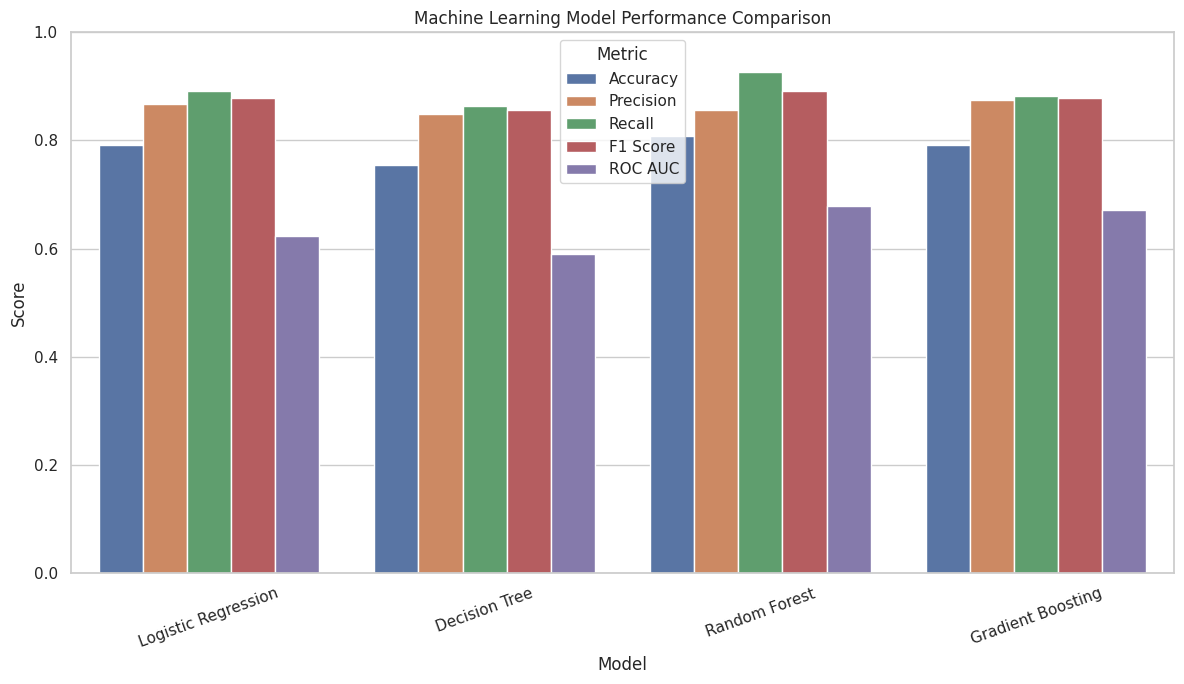

In [17]:
plot_data = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=plot_data,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Machine Learning Model Performance Comparison"
)

plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "week3_outputs/figures/model_comparison.png",
    dpi=300
)

plt.show()

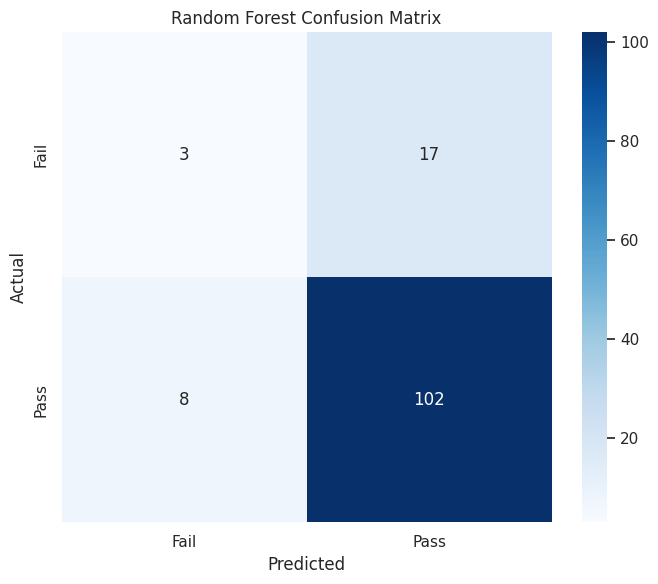

In [18]:
rf_model = trained_models[
    "Random Forest"
]

rf_predictions = rf_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=["Fail", "Pass"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "week3_outputs/figures/confusion_matrix.png",
    dpi=300
)

plt.show()

In [19]:
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

        Fail       0.27      0.15      0.19        20
        Pass       0.86      0.93      0.89       110

    accuracy                           0.81       130
   macro avg       0.56      0.54      0.54       130
weighted avg       0.77      0.81      0.78       130



<Figure size 900x700 with 0 Axes>

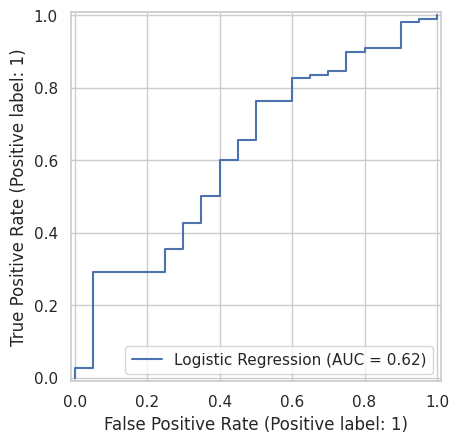

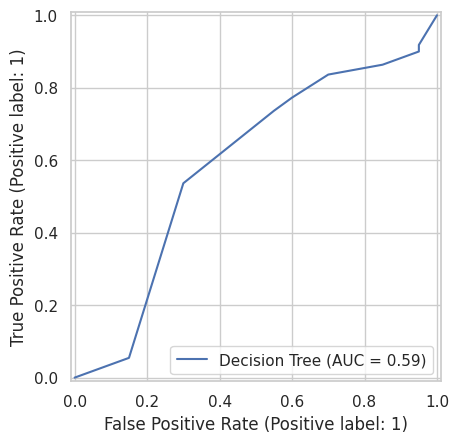

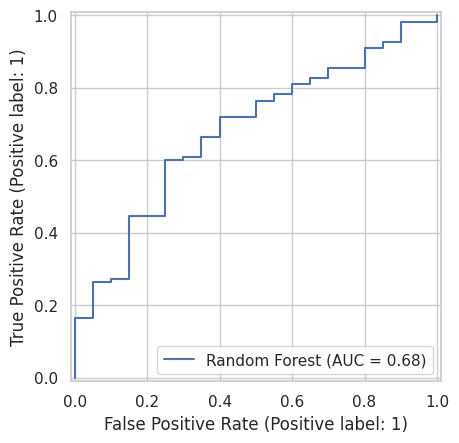

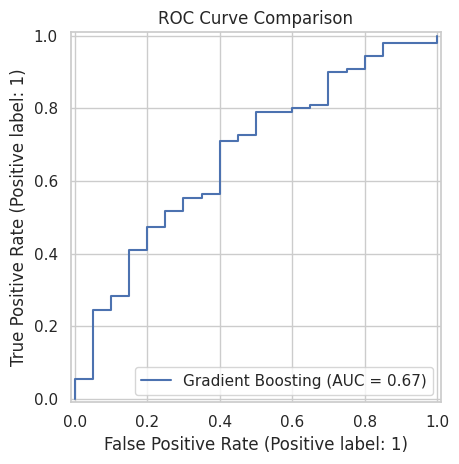

In [20]:
plt.figure(figsize=(9, 7))

actual_binary = (
    y_test == "Pass"
).astype(int)

for name, model in trained_models.items():

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    RocCurveDisplay.from_predictions(
        actual_binary,
        probabilities,
        name=name
    )

plt.title(
    "ROC Curve Comparison"
)

plt.tight_layout()

plt.savefig(
    "week3_outputs/figures/roc_curves.png",
    dpi=300
)

plt.show()

In [21]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in trained_models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    )

    cv_results.append({

        "Model": name,

        "CV Accuracy":
            scores["test_accuracy"].mean(),

        "CV Precision":
            scores["test_precision"].mean(),

        "CV Recall":
            scores["test_recall"].mean(),

        "CV F1":
            scores["test_f1"].mean(),

        "CV ROC AUC":
            scores["test_roc_auc"].mean()
    })

cv_df = pd.DataFrame(
    cv_results
)

cv_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC AUC
0,Logistic Regression,0.844341,NaN,NaN,NaN,0.786463
1,Decision Tree,0.832117,NaN,NaN,NaN,0.720155
2,Random Forest,0.852081,NaN,NaN,NaN,0.843683
3,Gradient Boosting,0.856744,NaN,NaN,NaN,0.806339


In [22]:
cv_df.to_csv(
    "week3_outputs/tables/cross_validation_results.csv",
    index=False
)

In [23]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

In [26]:
param_grid = {

    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__max_depth": [
        5,
        10,
        15,
        None
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ]
}

In [27]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 score:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV F1 score:
nan


In [28]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(
    X_test
)

best_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        best_predictions
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        (y_test == "Pass").astype(int),
        best_probabilities
    )
)

              precision    recall  f1-score   support

        Fail       0.29      0.10      0.15        20
        Pass       0.85      0.95      0.90       110

    accuracy                           0.82       130
   macro avg       0.57      0.53      0.52       130
weighted avg       0.77      0.82      0.79       130

ROC AUC: 0.6772727272727272


In [29]:
feature_names = (
    best_model
    .named_steps[
        "preprocessing"
    ]
    .get_feature_names_out()
)

importances = (
    best_model
    .named_steps[
        "model"
    ]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importances

}).sort_values(
    "Importance",
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
5,numeric__failures,0.142099
50,categorical__higher_no,0.070275
51,categorical__higher_yes,0.069579
13,categorical__school_GP,0.068682
14,categorical__school_MS,0.044922
12,numeric__absences,0.038931
8,numeric__goout,0.033000
6,numeric__famrel,0.032032
9,numeric__Dalc,0.031482
7,numeric__freetime,0.030278


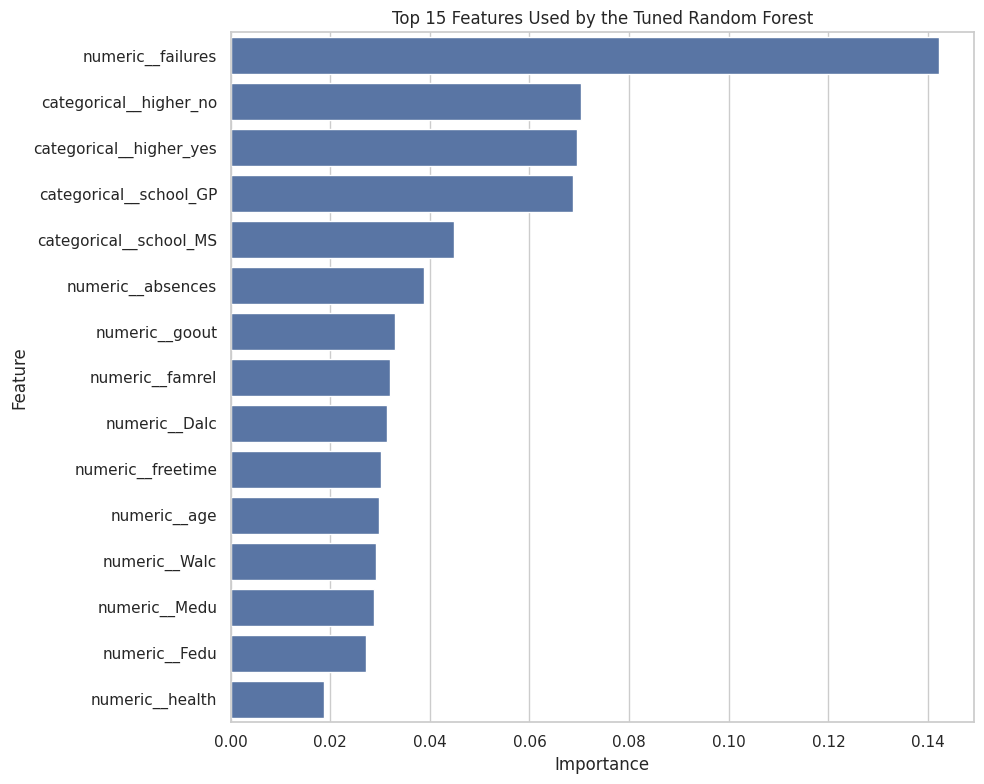

In [30]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features Used by the Tuned Random Forest"
)

plt.tight_layout()

plt.savefig(
    "week3_outputs/figures/feature_importance.png",
    dpi=300
)

plt.show()

In [31]:
joblib.dump(
    best_model,
    "week3_outputs/model/student_performance_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


In [32]:
sample_student = X_test.iloc[[0]]

prediction = best_model.predict(
    sample_student
)[0]

probability = best_model.predict_proba(
    sample_student
).max()

print("Predicted performance:", prediction)

print(
    "Prediction confidence:",
    round(probability * 100, 2),
    "%"
)

Predicted performance: Pass
Prediction confidence: 95.17 %


In [33]:
print("=" * 70)
print("MACHINE LEARNING SUMMARY")
print("=" * 70)

print("\nDataset:", df.shape)

print("\nModels:")
for model in models:
    print("-", model)

print("\nTest-set results:")
print(results_df)

print("\nCross-validation results:")
print(cv_df)

print("\nBest Random Forest parameters:")
print(grid_search.best_params_)

print(
    "\nBest cross-validation F1:",
    grid_search.best_score_
)

MACHINE LEARNING SUMMARY

Dataset: (649, 34)

Models:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Test-set results:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.792308   0.867257  0.890909  0.878924  0.622727
1        Decision Tree  0.753846   0.848214  0.863636  0.855856  0.589318
2        Random Forest  0.807692   0.857143  0.927273  0.890830  0.679545
3    Gradient Boosting  0.792308   0.873874  0.881818  0.877828  0.671364

Cross-validation results:
                 Model  CV Accuracy  CV Precision  CV Recall  CV F1  \
0  Logistic Regression     0.844341           NaN        NaN    NaN   
1        Decision Tree     0.832117           NaN        NaN    NaN   
2        Random Forest     0.852081           NaN        NaN    NaN   
3    Gradient Boosting     0.856744           NaN        NaN    NaN   

   CV ROC AUC  
0    0.786463  
1    0.720155  
2    0.843683  
3    0.806339  

Best Random Forest 